In [6]:
!pip install pyshark scapy matplotlib pandas -q
!apt-get install -y tshark

/usr/lib/python3.12/pathlib.py:407: RuntimeWarning: coroutine 'Capture._get_tshark_process' was never awaited
  def _load_parts(self):


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  libbcg729-0 libc-ares2 liblua5.2-0 libnl-genl-3-200 libpcap0.8 libsbc1
  libsmi2ldbl libspandsp2 libspeexdsp1 libwireshark-data libwireshark15
  libwiretap12 libwsutil13 wireshark-common
Suggested packages:
  snmp-mibs-downloader geoipupdate geoip-database geoip-database-extra
  libjs-leaflet libjs-leaflet.markercluster wireshark-doc
The following NEW packages will be installed:
  libbcg729-0 libc-ares2 liblua5.2-0 libnl-genl-3-200 libpcap0.8 libsbc1
  libsmi2ldbl libspandsp2 libspeexdsp1 libwireshark-data libwireshark15
  libwiretap12 libwsutil13 tshark wireshark-common
0 upgraded, 15 newly installed, 0 to remove and 2 not upgraded.
Need to get 23.0 MB of archives.
After this operation, 120 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 libpcap0.8 amd64 1.10.1-4ubuntu1.22.04.1 

In [2]:
from google.colab import files
uploaded = files.upload()

Saving 2018-01-11-Rig-EK-sends-SmokeLoader-and-Monero-coin-miner.pcap to 2018-01-11-Rig-EK-sends-SmokeLoader-and-Monero-coin-miner.pcap


In [3]:
import pyshark
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 150

In [8]:
import nest_asyncio
nest_asyncio.apply()

cap = pyshark.FileCapture('2018-01-11-Rig-EK-sends-SmokeLoader-and-Monero-coin-miner.pcap')

packets = []
for pkt in cap:
    try:
        packets.append({
            'time': float(pkt.sniff_timestamp),
            'src': pkt.ip.src,
            'dst': pkt.ip.dst,
            'length': int(pkt.length),
            'protocol': pkt.highest_layer
        })
    except:
        pass

df = pd.DataFrame(packets)
df['time'] = df['time'] - df['time'].min()
print(f"Total packets loaded: {len(df)}")

Total packets loaded: 4028


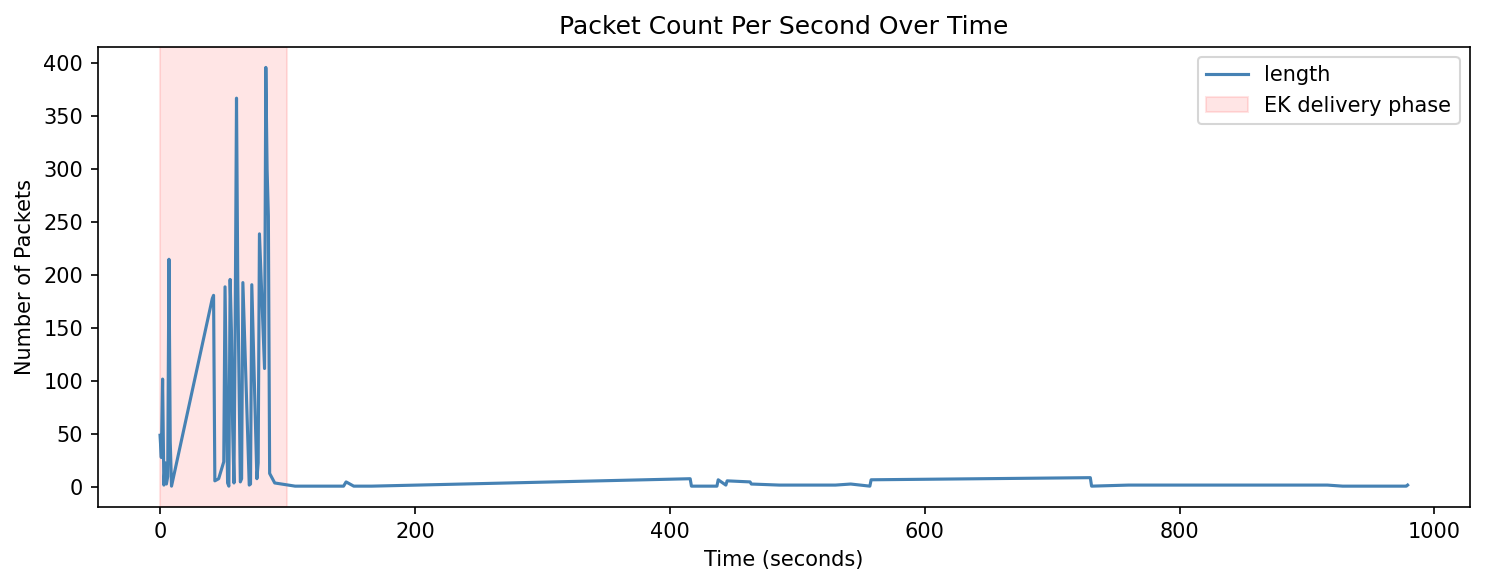

In [9]:
plt.figure(figsize=(10,4))
df.groupby(df['time'].astype(int))['length'].count().plot(color='steelblue')
plt.title('Packet Count Per Second Over Time')
plt.xlabel('Time (seconds)')
plt.ylabel('Number of Packets')
plt.axvspan(0, 100, alpha=0.1, color='red', label='EK delivery phase')
plt.legend()
plt.tight_layout()
plt.savefig('graph1_packet_count.png')
plt.show()

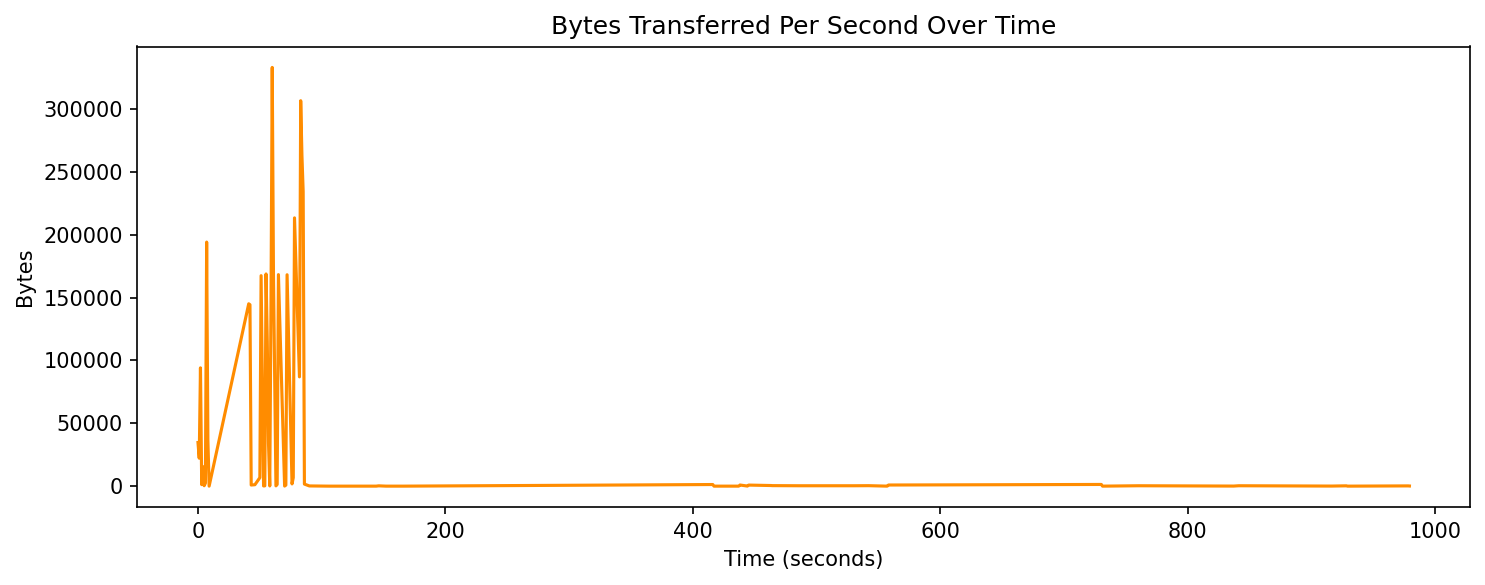

In [10]:
plt.figure(figsize=(10,4))
df.groupby(df['time'].astype(int))['length'].sum().plot(color='darkorange')
plt.title('Bytes Transferred Per Second Over Time')
plt.xlabel('Time (seconds)')
plt.ylabel('Bytes')
plt.tight_layout()
plt.savefig('graph2_bytes_over_time.png')
plt.show()

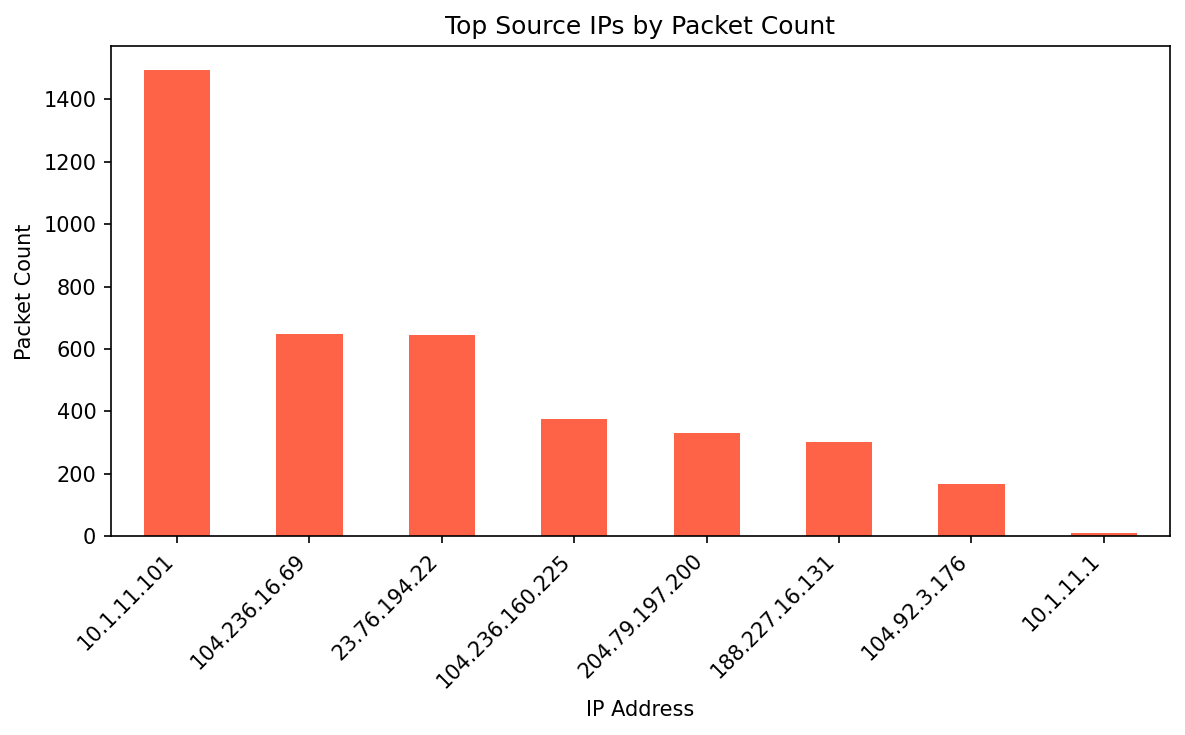

In [11]:
plt.figure(figsize=(8,5))
df['src'].value_counts().head(8).plot(kind='bar', color='tomato')
plt.title('Top Source IPs by Packet Count')
plt.xlabel('IP Address')
plt.ylabel('Packet Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('graph3_top_source_ips.png')
plt.show()

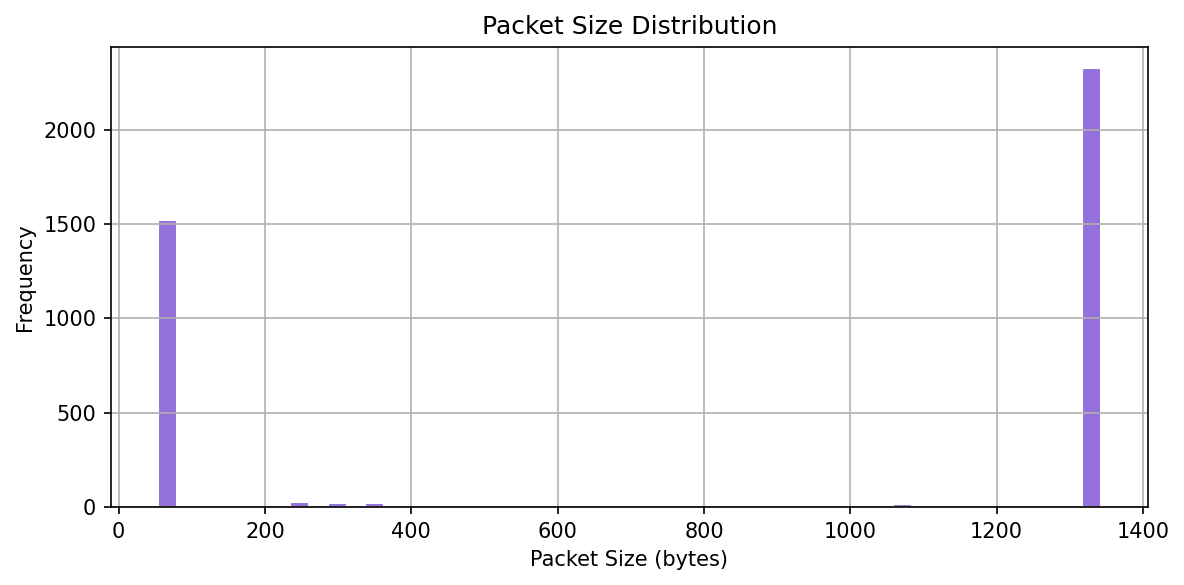

In [12]:
plt.figure(figsize=(8,4))
df['length'].hist(bins=50, color='mediumpurple', edgecolor='white')
plt.title('Packet Size Distribution')
plt.xlabel('Packet Size (bytes)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig('graph4_packet_size.png')
plt.show()

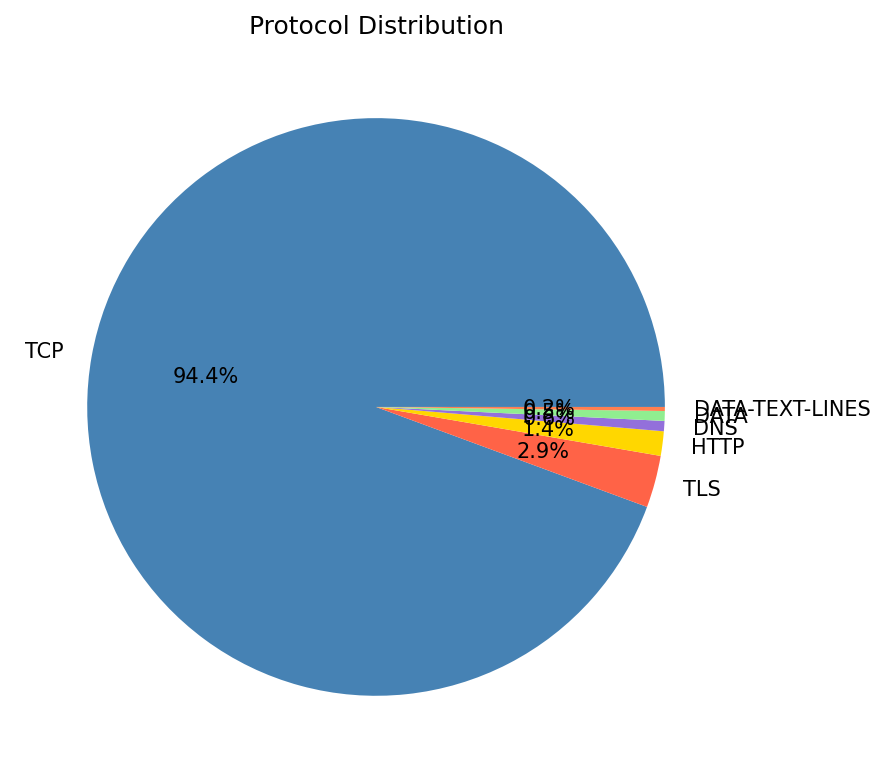

In [13]:
plt.figure(figsize=(6,6))
df['protocol'].value_counts().head(6).plot(kind='pie', autopct='%1.1f%%', colors=['steelblue','tomato','gold','mediumpurple','lightgreen','coral'])
plt.title('Protocol Distribution')
plt.ylabel('')
plt.tight_layout()
plt.savefig('graph5_protocol_distribution.png')
plt.show()